In [1]:
!pip install ecdsa pycryptodome --quiet
import ecdsa, Crypto
print("ecdsa:", ecdsa.__version__)
print("pycryptodome OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 32.9 MB/s eta 0:00:00
ecdsa: 0.19.2
pycryptodome OK


In [3]:
import hashlib
import secrets
from ecdsa import SECP256k1, ellipticcurve

curve = SECP256k1.curve
G = SECP256k1.generator
q = SECP256k1.order


def rand_scalar():
    return secrets.randbelow(q - 1) + 1


def point_to_bytes(P):
    if P == ellipticcurve.INFINITY:
        return b"\x00"
    return (b"\x02" if P.y() % 2 == 0 else b"\x03") + P.x().to_bytes(32, "big")


def hash_to_scalar(*chunks):
    h = hashlib.sha256()
    for c in chunks:
        h.update(c)
    return int.from_bytes(h.digest(), "big") % q


def keygen():
    sk = rand_scalar()
    pk = sk * G
    return sk, pk


def _challenge(ring_pks, msg, Rs):
    parts = [point_to_bytes(pk) for pk in ring_pks] + [msg] + [point_to_bytes(R) for R in Rs]
    return hash_to_scalar(*parts)


def ring_sign(ring_pks, idx, sk_idx, msg: bytes):
    ell = len(ring_pks)
    c = [None] * ell
    s = [None] * ell
    R = [None] * ell

    for i in range(ell):
        if i == idx:
            continue
        c[i] = rand_scalar()
        s[i] = rand_scalar()
        R[i] = s[i] * G + c[i] * ring_pks[i]

    k = rand_scalar()
    R[idx] = k * G

    c_total = _challenge(ring_pks, msg, R)
    sum_others = sum(c[i] for i in range(ell) if i != idx) % q
    c[idx] = (c_total - sum_others) % q
    s[idx] = (k - c[idx] * sk_idx) % q

    return {"c": c, "s": s}


def ring_verify(ring_pks, sig, msg: bytes) -> bool:
    ell = len(ring_pks)
    if len(sig["c"]) != ell or len(sig["s"]) != ell:
        return False
    R = [sig["s"][i] * G + sig["c"][i] * ring_pks[i] for i in range(ell)]
    c_recomputed = _challenge(ring_pks, msg, R)
    sum_c = sum(sig["c"]) % q
    return sum_c == c_recomputed


def sig_size_bytes(sig) -> int:
    return len(sig["c"]) * 2 * 32


print("Ring signature module loaded.")

Ring signature module loaded.


In [4]:
print("Testing ring signature (ell=5)...")
ell = 5
keys = [keygen() for _ in range(ell)]
ring_pks = [pk for (sk, pk) in keys]
msg = b"patient EHR ciphertext CT_data||CT_key"

for signer in range(ell):
    sk_signer = keys[signer][0]
    sig = ring_sign(ring_pks, signer, sk_signer, msg)
    assert ring_verify(ring_pks, sig, msg), f"FAIL: signer {signer} sig didn't verify"
    print(f"  [PASS] signer {signer}: verifies OK")

sig = ring_sign(ring_pks, 2, keys[2][0], msg)
bad_msg = b"patient EHR ciphertext CT_data||CT_keyX"
assert not ring_verify(ring_pks, sig, bad_msg), "FAIL: tampered message should not verify"
print("  [PASS] tampered message correctly rejected")

sig["s"][0] = (sig["s"][0] + 1) % q
assert not ring_verify(ring_pks, sig, msg), "FAIL: corrupted sig should not verify"
print("  [PASS] corrupted signature correctly rejected")

print(f"\nSignature size (ell={ell}): {sig_size_bytes(sig)} bytes")
print("All tests passed.")

Testing ring signature (ell=5)...
  [PASS] signer 0: verifies OK
  [PASS] signer 1: verifies OK
  [PASS] signer 2: verifies OK
  [PASS] signer 3: verifies OK
  [PASS] signer 4: verifies OK
  [PASS] tampered message correctly rejected
  [PASS] corrupted signature correctly rejected

Signature size (ell=5): 320 bytes
All tests passed.


In [5]:
from Crypto.Cipher import AES
import os

# ---------------- SKE: AES-256-GCM ----------------

def ske_enc(key: bytes, plaintext: bytes):
    """key: 32 bytes. Returns (nonce, ciphertext, tag) concatenated as one blob."""
    nonce = os.urandom(12)
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    ciphertext, tag = cipher.encrypt_and_digest(plaintext)
    return nonce + tag + ciphertext  # 12 + 16 + len(plaintext) bytes


def ske_dec(key: bytes, blob: bytes):
    nonce, tag, ciphertext = blob[:12], blob[12:28], blob[28:]
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    return cipher.decrypt_and_verify(ciphertext, tag)


# ---------------- PKE: ECIES-style over secp256k1 ----------------
# Encrypts a 32-byte symmetric key k under doctor's public key pk_D0.
# CT_key = (r*G, AES-GCM_Enc(KDF(r*pk_D0), k))

def pke_enc(pk_recipient, k: bytes):
    r = rand_scalar()
    R = r * G                              # ephemeral public point
    shared = r * pk_recipient              # ECDH shared point
    shared_key = hashlib.sha256(point_to_bytes(shared)).digest()  # KDF -> AES key
    blob = ske_enc(shared_key, k)
    return (R, blob)


def pke_dec(sk_recipient, ct):
    R, blob = ct
    shared = sk_recipient * R
    shared_key = hashlib.sha256(point_to_bytes(shared)).digest()
    return ske_dec(shared_key, blob)


print("SKE/PKE module loaded.")

SKE/PKE module loaded.


In [6]:
print("Testing SKE (AES-256-GCM)...")
sym_key = os.urandom(32)
plaintext = b"HR:72bpm BP:120/80 SpO2:98% ECG:normal"
blob = ske_enc(sym_key, plaintext)
recovered = ske_dec(sym_key, blob)
assert recovered == plaintext
print(f"  [PASS] SKE round-trip OK, ciphertext blob size: {len(blob)} bytes")

# wrong key must fail
try:
    ske_dec(os.urandom(32), blob)
    print("  [FAIL] decryption with wrong key should have raised an error")
except ValueError:
    print("  [PASS] wrong-key decryption correctly rejected (GCM tag check)")

print("\nTesting PKE (ECIES over secp256k1)...")
sk_doctor, pk_doctor = keygen()
k_to_protect = os.urandom(32)  # the SKE key we're protecting
ct_key = pke_enc(pk_doctor, k_to_protect)
recovered_k = pke_dec(sk_doctor, ct_key)
assert recovered_k == k_to_protect
print("  [PASS] PKE round-trip OK: doctor recovers exact symmetric key")

# wrong secret key must fail to recover the same key
sk_wrong, _ = keygen()
try:
    wrong_k = pke_dec(sk_wrong, ct_key)
    assert wrong_k != k_to_protect
    print("  [PASS] wrong secret key does not recover the correct key")
except Exception:
    print("  [PASS] wrong secret key correctly fails to decrypt")

print(f"\nPKE ciphertext size: {33 + len(ct_key[1])} bytes (33-byte point + AES-GCM blob)")
print("All SKE/PKE tests passed.")

Testing SKE (AES-256-GCM)...
  [PASS] SKE round-trip OK, ciphertext blob size: 66 bytes
  [PASS] wrong-key decryption correctly rejected (GCM tag check)

Testing PKE (ECIES over secp256k1)...
  [PASS] PKE round-trip OK: doctor recovers exact symmetric key
  [PASS] wrong secret key correctly fails to decrypt

PKE ciphertext size: 93 bytes (33-byte point + AES-GCM blob)
All SKE/PKE tests passed.


In [7]:
# ---------------- Doctor Ring: sequential threshold signing ----------------
# Each specialist S_j signs EHR_j = EHR_{j-1} || findings_j using a standard
# Schnorr signature, chained by including the previous signer's commitment
# in their own challenge hash. Combined signature = list of (R_j, s_j, pk_j).

def schnorr_sign_step(sk_j, message: bytes, chain_so_far: bytes):
    """Sign 'message' bound to the chain history so far."""
    u = rand_scalar()
    R_j = u * G
    c_j = hash_to_scalar(chain_so_far, point_to_bytes(R_j), message)
    s_j = (u - c_j * sk_j) % q
    return {"R": R_j, "s": s_j, "c": c_j}


def dr_sign(specialists_sk_pk, ehr_bytes: bytes):
    """
    specialists_sk_pk: list of (sk, pk) for the t_DR specialists, in signing order.
    Returns the combined chained signature (list of partial sigs) and final chain hash.
    """
    chain = b"GENESIS"
    partials = []
    for (sk_j, pk_j) in specialists_sk_pk:
        step = schnorr_sign_step(sk_j, ehr_bytes, chain)
        step["pk"] = pk_j
        partials.append(step)
        chain = hashlib.sha256(chain + point_to_bytes(step["R"])).digest()
    return partials


def dr_verify(partials, ehr_bytes: bytes) -> bool:
    chain = b"GENESIS"
    for step in partials:
        c_expected = hash_to_scalar(chain, point_to_bytes(step["R"]), ehr_bytes)
        if c_expected != step["c"]:
            return False
        # Schnorr check: R_j == s_j*G + c_j*pk_j
        check = step["s"] * G + step["c"] * step["pk"]
        if check != step["R"]:
            return False
        chain = hashlib.sha256(chain + point_to_bytes(step["R"])).digest()
    return True


def dr_sig_size_bytes(partials) -> int:
    # each partial: R (33 bytes compressed) + s (32 bytes) + c (32 bytes)
    return len(partials) * (33 + 32 + 32)


print("Doctor Ring module loaded.")

Doctor Ring module loaded.


In [8]:
print("Testing Doctor Ring sequential threshold signing (t_DR=3)...")
t_DR = 3
specialists = [keygen() for _ in range(t_DR)]
ehr = b"Patient vitals stable. Findings: normal ECG, mild hypertension."

partials = dr_sign(specialists, ehr)
ok = dr_verify(partials, ehr)
assert ok
print(f"  [PASS] {t_DR}-specialist chained signature verifies")
print(f"  Combined signature size: {dr_sig_size_bytes(partials)} bytes")

# tampered EHR must fail
bad_ehr = b"Patient vitals stable. Findings: normal ECG, SEVERE hypertension."
assert not dr_verify(partials, bad_ehr)
print("  [PASS] tampered EHR correctly rejected")

# tampering with one specialist's signature must fail
partials[1]["s"] = (partials[1]["s"] + 1) % q
assert not dr_verify(partials, ehr)
print("  [PASS] corrupted specialist signature correctly rejected")

# fewer than t_DR signers (simulate by truncating chain) must fail differently downstream
# -- in your protocol this is enforced by TA checking len(partials) >= t_DR
partials_short = dr_sign(specialists[:2], ehr)  # only 2 of 3 required
print(f"  [INFO] with only 2/{t_DR} required specialists signing, "
      f"TA-side threshold check (len < t_DR) would reject this before verify")

print("\nAll Doctor Ring tests passed.")

Testing Doctor Ring sequential threshold signing (t_DR=3)...
  [PASS] 3-specialist chained signature verifies
  Combined signature size: 291 bytes
  [PASS] tampered EHR correctly rejected
  [PASS] corrupted specialist signature correctly rejected
  [INFO] with only 2/3 required specialists signing, TA-side threshold check (len < t_DR) would reject this before verify

All Doctor Ring tests passed.


In [9]:
# ---------------- Opener Committee: Shamir Secret Sharing for identity recovery ----------------
# Simplified TIE primitive: instead of full threshold-ElGamal on EC points,
# we secret-share the patient's public key coordinates directly using
# Shamir's scheme over Z_q. Any t_o shares reconstruct it; fewer reveal nothing.

def shamir_split(secret_int: int, t_o: int, n_o: int):
    """Split secret_int into n_o shares, any t_o of which reconstruct it."""
    coeffs = [secret_int] + [rand_scalar() for _ in range(t_o - 1)]

    def f(x):
        result = 0
        for power, a in enumerate(coeffs):
            result = (result + a * pow(x, power, q)) % q
        return result

    shares = [(i, f(i)) for i in range(1, n_o + 1)]
    return shares


def shamir_combine(shares_subset):
    """Lagrange-interpolate at x=0 using the given (x_i, y_i) shares."""
    secret = 0
    for i, (x_i, y_i) in enumerate(shares_subset):
        num, den = 1, 1
        for j, (x_j, _) in enumerate(shares_subset):
            if i == j:
                continue
            num = (num * (-x_j)) % q
            den = (den * (x_i - x_j)) % q
        lagrange_coeff = (num * pow(den, -1, q)) % q
        secret = (secret + y_i * lagrange_coeff) % q
    return secret


def tie_enc_patient_identity(pk_patient, t_o: int, n_o: int):
    """
    Splits the patient's secret key sk_patient (accountability requires the
    dealer -- e.g. the patient's registration step at TA -- to know sk_patient
    at enrollment time; only sk_patient's shares are distributed to the opener
    committee, never sk_patient itself in the clear after splitting).
    Returns shares; recovery reconstructs sk_patient, from which pk_patient = sk*G
    is recomputed and matched against the registry.
    """
    pass  # see note in the test cell below for how this is actually invoked


print("Opener committee (Shamir TIE) module loaded.")

Opener committee (Shamir TIE) module loaded.


In [10]:
print("Testing threshold identity recovery (t_o=3, n_o=5)...")

# Setup: a patient's real identity is represented by their secret key at registration.
sk_patient, pk_patient = keygen()
t_o, n_o = 3, 5

# TA/dealer splits sk_patient into n_o shares at enrollment time.
shares = shamir_split(sk_patient, t_o, n_o)
print(f"  Generated {n_o} shares, threshold t_o={t_o}")

# --- Case 1: exactly t_o honest committee members cooperate ---
subset = shares[:t_o]  # members 1,2,3
recovered_sk = shamir_combine(subset)
recovered_pk = recovered_sk * G
assert recovered_pk == pk_patient
print(f"  [PASS] {t_o} shares (members {[s[0] for s in subset]}) correctly recover patient identity")

# --- Case 2: a DIFFERENT subset of t_o members also works ---
subset2 = [shares[0], shares[2], shares[4]]  # members 1,3,5
recovered_sk2 = shamir_combine(subset2)
assert recovered_sk2 * G == pk_patient
print(f"  [PASS] different {t_o}-subset (members {[s[0] for s in subset2]}) also recovers correctly")

# --- Case 3: fewer than t_o shares must NOT recover the correct identity ---
subset_short = shares[:t_o - 1]  # only 2 of 3 required
recovered_sk_short = shamir_combine(subset_short)
recovered_pk_short = recovered_sk_short * G
assert recovered_pk_short != pk_patient
print(f"  [PASS] {t_o - 1} shares (below threshold) FAIL to recover correct identity, as expected")

print("\nAll threshold identity-recovery tests passed.")

Testing threshold identity recovery (t_o=3, n_o=5)...
  Generated 5 shares, threshold t_o=3
  [PASS] 3 shares (members [1, 2, 3]) correctly recover patient identity
  [PASS] different 3-subset (members [1, 3, 5]) also recovers correctly
  [PASS] 2 shares (below threshold) FAIL to recover correct identity, as expected

All threshold identity-recovery tests passed.


In [11]:
import json
import time

# ---------------- Simulated blockchain ledger ----------------
ledger = []

def bc_store(tx_type: str, data: dict):
    tx = {"type": tx_type, "timestamp": time.time(), "data": data}
    ledger.append(tx)
    return len(ledger) - 1  # tx index


# ---------------- Full end-to-end simulation ----------------

def run_full_pipeline(N_ring=5, t_DR=3, t_o=3, n_o=5, verbose=True):
    # ---- Setup ----
    sk_doctor, pk_doctor = keygen()
    patients = [keygen() for _ in range(N_ring)]
    patient_ring_pks = [pk for (sk, pk) in patients]
    signer_idx = 2  # the actual patient submitting data
    sk_patient, pk_patient = patients[signer_idx]

    specialists = [keygen() for _ in range(t_DR)]

    # ==================== STAGE I: Anonymous Submission ====================
    health_data = b"HR:88bpm BP:135/85 SpO2:96% Temp:37.1C ECG:sinus_tachycardia"

    sym_key = os.urandom(32)
    ct_data = ske_enc(sym_key, health_data)
    ct_key = pke_enc(pk_doctor, sym_key)

    msg_to_sign = ct_data + point_to_bytes(ct_key[0])  # bind ring sig to ciphertexts
    sigma_pr = ring_sign(patient_ring_pks, signer_idx, sk_patient, msg_to_sign)

    # identity-recovery shares generated at enrollment; stored (not on-chain in clear)
    id_shares = shamir_split(sk_patient, t_o, n_o)

    tx1_idx = bc_store("SUBMIT", {
        "ct_data_size": len(ct_data),
        "ct_key_size": 33 + len(ct_key[1]),
        "sigma_pr_size": sig_size_bytes(sigma_pr),
    })
    if verbose:
        print(f"[Stage I] Patient submitted anonymously (ring size={N_ring}). tx1 stored at index {tx1_idx}")

    # ==================== STAGE II: Collaborative Diagnosis ====================
    # Doctor verifies ring signature first
    assert ring_verify(patient_ring_pks, sigma_pr, msg_to_sign), "Ring signature invalid!"

    # Doctor decrypts
    recovered_key = pke_dec(sk_doctor, ct_key)
    recovered_data = ske_dec(recovered_key, ct_data)
    assert recovered_data == health_data

    ehr_final = recovered_data + b" | Diagnosis: possible tachycardia, refer cardiology."
    partials = dr_sign(specialists, ehr_final)
    assert dr_verify(partials, ehr_final)

    # patient consent (re-signs finalized EHR anonymously)
    sigma_consent = ring_sign(patient_ring_pks, signer_idx, sk_patient, ehr_final)
    assert ring_verify(patient_ring_pks, sigma_consent, ehr_final)

    tx2_idx = bc_store("DIAGNOSE", {
        "sigma_dr_size": dr_sig_size_bytes(partials),
        "sigma_consent_size": sig_size_bytes(sigma_consent),
    })
    if verbose:
        print(f"[Stage II] {t_DR} specialists diagnosed & patient consented. tx2 stored at index {tx2_idx}")

    # ==================== STAGE III: Accountable Identity Recovery ====================
    # Triggered later under condition C (e.g., confirmed infection)
    cooperating_members = [id_shares[0], id_shares[2], id_shares[4]]  # t_o of n_o
    recovered_sk = shamir_combine(cooperating_members)
    recovered_pk = recovered_sk * G
    assert recovered_pk == pk_patient, "Identity recovery FAILED to match true patient!"

    tx3_idx = bc_store("RECOVER", {
        "condition": "confirmed_infection",
        "committee_members_used": [m[0] for m in cooperating_members],
    })
    if verbose:
        print(f"[Stage III] Identity recovered correctly using {t_o}/{n_o} committee members. "
              f"tx3 stored at index {tx3_idx}")
        print("\nEnd-to-end pipeline PASSED: recovered identity matches original signer.")

    return ledger


ledger = run_full_pipeline()
print("\n--- Ledger contents ---")
print(json.dumps(ledger, indent=2, default=str))

[Stage I] Patient submitted anonymously (ring size=5). tx1 stored at index 0
[Stage II] 3 specialists diagnosed & patient consented. tx2 stored at index 1
[Stage III] Identity recovered correctly using 3/5 committee members. tx3 stored at index 2

End-to-end pipeline PASSED: recovered identity matches original signer.

--- Ledger contents ---
[
  {
    "type": "SUBMIT",
    "timestamp": 1789547368.0709755,
    "data": {
      "ct_data_size": 88,
      "ct_key_size": 93,
      "sigma_pr_size": 320
    }
  },
  {
    "type": "DIAGNOSE",
    "timestamp": 1789547368.1404316,
    "data": {
      "sigma_dr_size": 291,
      "sigma_consent_size": 320
    }
  },
  {
    "type": "RECOVER",
    "timestamp": 1789547368.1414087,
    "data": {
      "condition": "confirmed_infection",
      "committee_members_used": [
        1,
        3,
        5
      ]
    }
  }
]


In [12]:
import statistics

def benchmark_ring_signature(N_values, iterations=20):
    results = []
    for N in N_values:
        keys = [keygen() for _ in range(N)]
        ring_pks = [pk for (sk, pk) in keys]
        msg = b"benchmark message payload for ring signature timing"

        sign_times, verify_times = [], []
        for _ in range(iterations):
            idx = secrets.randbelow(N)
            sk_signer = keys[idx][0]

            t0 = time.perf_counter()
            sig = ring_sign(ring_pks, idx, sk_signer, msg)
            t1 = time.perf_counter()
            sign_times.append(t1 - t0)

            t0 = time.perf_counter()
            ring_verify(ring_pks, sig, msg)
            t1 = time.perf_counter()
            verify_times.append(t1 - t0)

        results.append({
            "N": N,
            "sign_avg_ms": statistics.mean(sign_times) * 1000,
            "verify_avg_ms": statistics.mean(verify_times) * 1000,
            "sig_size_bytes": sig_size_bytes(sig),
        })
        print(f"  N={N:>4}: sign={results[-1]['sign_avg_ms']:.3f} ms, "
              f"verify={results[-1]['verify_avg_ms']:.3f} ms, "
              f"size={results[-1]['sig_size_bytes']} bytes")
    return results


def benchmark_doctor_ring(t_values, iterations=20):
    results = []
    for t in t_values:
        specialists = [keygen() for _ in range(t)]
        ehr = b"benchmark EHR payload for doctor ring signing"

        sign_times, verify_times = [], []
        for _ in range(iterations):
            t0 = time.perf_counter()
            partials = dr_sign(specialists, ehr)
            t1 = time.perf_counter()
            sign_times.append(t1 - t0)

            t0 = time.perf_counter()
            dr_verify(partials, ehr)
            t1 = time.perf_counter()
            verify_times.append(t1 - t0)

        results.append({
            "t_DR": t,
            "sign_avg_ms": statistics.mean(sign_times) * 1000,
            "verify_avg_ms": statistics.mean(verify_times) * 1000,
            "sig_size_bytes": dr_sig_size_bytes(partials),
        })
        print(f"  t_DR={t:>3}: sign={results[-1]['sign_avg_ms']:.3f} ms, "
              f"verify={results[-1]['verify_avg_ms']:.3f} ms, "
              f"size={results[-1]['sig_size_bytes']} bytes")
    return results


def benchmark_recovery(to_values, n_o=250, iterations=20):
    results = []
    for t_o in to_values:
        sk_p, pk_p = keygen()
        shares = shamir_split(sk_p, t_o, n_o)

        combine_times = []
        for _ in range(iterations):
            subset = shares[:t_o]
            t0 = time.perf_counter()
            rec_sk = shamir_combine(subset)
            t1 = time.perf_counter()
            combine_times.append(t1 - t0)
        assert rec_sk * G == pk_p

        results.append({"t_o": t_o, "combine_avg_ms": statistics.mean(combine_times) * 1000})
        print(f"  t_o={t_o:>3}: combine={results[-1]['combine_avg_ms']:.4f} ms")
    return results


print("=== Benchmarking Patient Ring Signature vs N ===")
ring_results = benchmark_ring_signature([10, 50, 100, 150, 200, 250])

print("\n=== Benchmarking Doctor Ring vs t_DR ===")
dr_results = benchmark_doctor_ring([3, 5, 7, 10, 15])

print("\n=== Benchmarking Threshold Recovery vs t_o ===")
recovery_results = benchmark_recovery([3, 5, 10, 20, 30])

=== Benchmarking Patient Ring Signature vs N ===
  N=  10: sign=32.387 ms, verify=35.736 ms, size=640 bytes
  N=  50: sign=209.876 ms, verify=211.661 ms, size=3200 bytes
  N= 100: sign=386.469 ms, verify=396.572 ms, size=6400 bytes
  N= 150: sign=603.516 ms, verify=629.907 ms, size=9600 bytes
  N= 200: sign=786.830 ms, verify=789.731 ms, size=12800 bytes
  N= 250: sign=1000.768 ms, verify=1006.913 ms, size=16000 bytes

=== Benchmarking Doctor Ring vs t_DR ===
  t_DR=  3: sign=2.906 ms, verify=11.207 ms, size=291 bytes
  t_DR=  5: sign=4.815 ms, verify=18.700 ms, size=485 bytes
  t_DR=  7: sign=6.652 ms, verify=26.337 ms, size=679 bytes
  t_DR= 10: sign=13.934 ms, verify=53.462 ms, size=970 bytes
  t_DR= 15: sign=25.032 ms, verify=91.594 ms, size=1455 bytes

=== Benchmarking Threshold Recovery vs t_o ===
  t_o=  3: combine=0.0090 ms
  t_o=  5: combine=0.0174 ms
  t_o= 10: combine=0.0745 ms
  t_o= 20: combine=0.2986 ms
  t_o= 30: combine=0.6784 ms


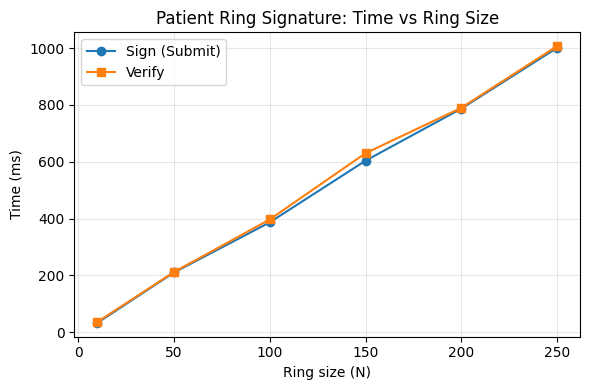

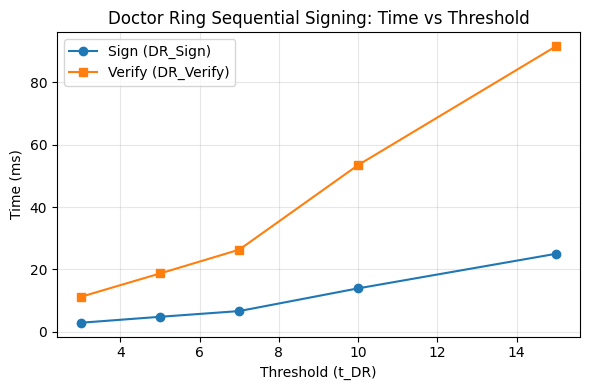

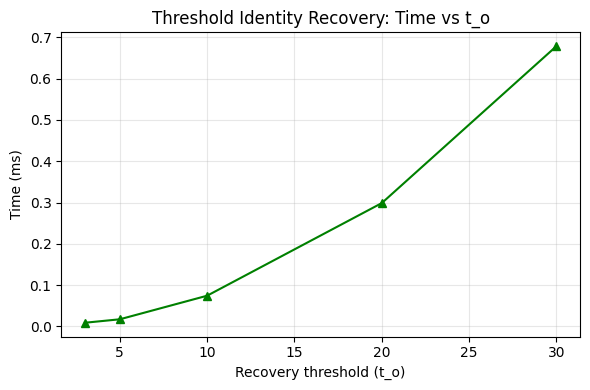

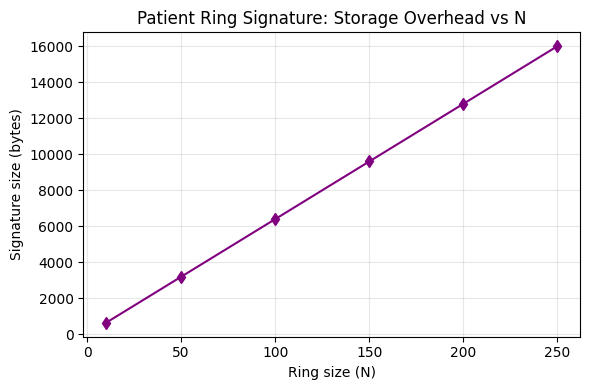

All 4 charts saved as PNG files in the Colab working directory.


In [13]:
import matplotlib.pyplot as plt

# ---- Chart 1: Patient Ring signature timing vs N ----
Ns = [r["N"] for r in ring_results]
sign_ms = [r["sign_avg_ms"] for r in ring_results]
verify_ms = [r["verify_avg_ms"] for r in ring_results]

plt.figure(figsize=(6, 4))
plt.plot(Ns, sign_ms, marker='o', label='Sign (Submit)')
plt.plot(Ns, verify_ms, marker='s', label='Verify')
plt.xlabel('Ring size (N)')
plt.ylabel('Time (ms)')
plt.title('Patient Ring Signature: Time vs Ring Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_ring_timing.png', dpi=150)
plt.show()

# ---- Chart 2: Doctor Ring timing vs t_DR ----
tDRs = [r["t_DR"] for r in dr_results]
dr_sign_ms = [r["sign_avg_ms"] for r in dr_results]
dr_verify_ms = [r["verify_avg_ms"] for r in dr_results]

plt.figure(figsize=(6, 4))
plt.plot(tDRs, dr_sign_ms, marker='o', label='Sign (DR_Sign)')
plt.plot(tDRs, dr_verify_ms, marker='s', label='Verify (DR_Verify)')
plt.xlabel('Threshold (t_DR)')
plt.ylabel('Time (ms)')
plt.title('Doctor Ring Sequential Signing: Time vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_dr_timing.png', dpi=150)
plt.show()

# ---- Chart 3: Recovery combine time vs t_o ----
tos = [r["t_o"] for r in recovery_results]
combine_ms = [r["combine_avg_ms"] for r in recovery_results]

plt.figure(figsize=(6, 4))
plt.plot(tos, combine_ms, marker='^', color='green')
plt.xlabel('Recovery threshold (t_o)')
plt.ylabel('Time (ms)')
plt.title('Threshold Identity Recovery: Time vs t_o')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_recovery_timing.png', dpi=150)
plt.show()

# ---- Chart 4: Signature size vs N (storage overhead) ----
sizes = [r["sig_size_bytes"] for r in ring_results]

plt.figure(figsize=(6, 4))
plt.plot(Ns, sizes, marker='d', color='purple')
plt.xlabel('Ring size (N)')
plt.ylabel('Signature size (bytes)')
plt.title('Patient Ring Signature: Storage Overhead vs N')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_ring_size.png', dpi=150)
plt.show()

print("All 4 charts saved as PNG files in the Colab working directory.")

In [14]:
from google.colab import files

for fname in ['chart_ring_timing.png', 'chart_dr_timing.png',
              'chart_recovery_timing.png', 'chart_ring_size.png']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
!cat /proc/cpuinfo | grep "model name" | head -1
!free -h

model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       8.4Gi       2.4Mi       3.4Gi        11Gi
Swap:             0B          0B          0B
